In [41]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [42]:
iris_df=pd.read_csv('/content/Iris (1).csv')

In [43]:
iris_df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [44]:
iris_df.shape

(150, 6)

In [45]:
iris_df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [46]:
x_variable= iris_df.iloc[:,1:5]
x_variable

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [47]:
y_var = iris_df.iloc[:,5]
y_var

,Species
0,Iris-setosa
1,Iris-setosa
2,Iris-setosa
3,Iris-setosa
4,Iris-setosa
...,...
145,Iris-virginica
146,Iris-virginica
147,Iris-virginica
148,Iris-virginica


In [48]:
sc=StandardScaler()
transformed_df =sc.fit_transform(x_variable)

In [49]:
transformed_df

array([[-9.00681170e-01,  1.03205722e+00, -1.34127240e+00,
        -1.31297673e+00],
       [-1.14301691e+00, -1.24957601e-01, -1.34127240e+00,
        -1.31297673e+00],
       [-1.38535265e+00,  3.37848329e-01, -1.39813811e+00,
        -1.31297673e+00],
       [-1.50652052e+00,  1.06445364e-01, -1.28440670e+00,
        -1.31297673e+00],
       [-1.02184904e+00,  1.26346019e+00, -1.34127240e+00,
        -1.31297673e+00],
       [-5.37177559e-01,  1.95766909e+00, -1.17067529e+00,
        -1.05003079e+00],
       [-1.50652052e+00,  8.00654259e-01, -1.34127240e+00,
        -1.18150376e+00],
       [-1.02184904e+00,  8.00654259e-01, -1.28440670e+00,
        -1.31297673e+00],
       [-1.74885626e+00, -3.56360566e-01, -1.34127240e+00,
        -1.31297673e+00],
       [-1.14301691e+00,  1.06445364e-01, -1.28440670e+00,
        -1.44444970e+00],
       [-5.37177559e-01,  1.49486315e+00, -1.28440670e+00,
        -1.31297673e+00],
       [-1.26418478e+00,  8.00654259e-01, -1.22754100e+00,
      

In [50]:
covariance_matrix = np.cov(transformed_df.T)

In [51]:
covariance_matrix

array([[ 1.00671141, -0.11010327,  0.87760486,  0.82344326],
       [-0.11010327,  1.00671141, -0.42333835, -0.358937  ],
       [ 0.87760486, -0.42333835,  1.00671141,  0.96921855],
       [ 0.82344326, -0.358937  ,  0.96921855,  1.00671141]])

In [52]:
eigen_values, eigen_vectors = np.linalg.eigh(covariance_matrix)

In [53]:
eigen_values

array([0.02074601, 0.14834223, 0.92740362, 2.93035378])

In [54]:
eigen_pairs = [(np.abs(eigen_values[i]), eigen_vectors[:, i]) for i in range(len(eigen_values))]
print("Eigen values arranged in descending order")
for i in eigen_pairs:
    print(i[0])

Eigen values arranged in descending order
0.02074601399559607
0.14834222648163967
0.9274036215173415
2.9303537755893165


In [55]:
pca= PCA()

In [56]:
pca = pca.fit(transformed_df)

In [57]:
#extract explained variansce ratios
explained_variance = pca.explained_variance_ratio_

In [58]:
explained_variance

array([0.72770452, 0.23030523, 0.03683832, 0.00515193])

In [59]:
#create PCA object
#creating dataframe to store variance
dataframe = pd.DataFrame({'variance':pca.explained_variance_ratio_,'Principal Component':['PC1','PC2','PC3','PC4']})
dataframe

,variance,Principal Component
0,0.727705,PC1
1,0.230305,PC2
2,0.036838,PC3
3,0.005152,PC4


<Axes: xlabel='Principal Component', ylabel='variance'>

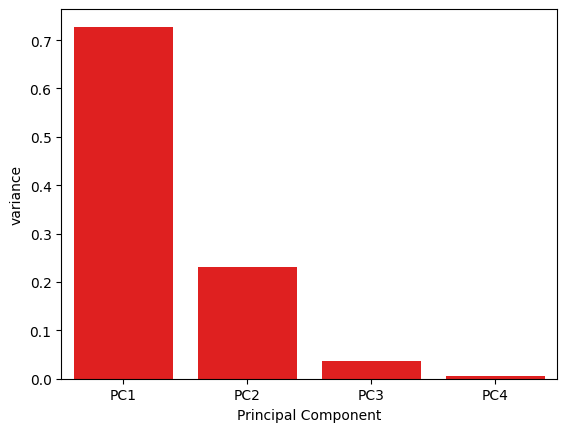

In [60]:
sns.barplot(x = 'Principal Component', y = 'variance', data = dataframe, color = "Red")

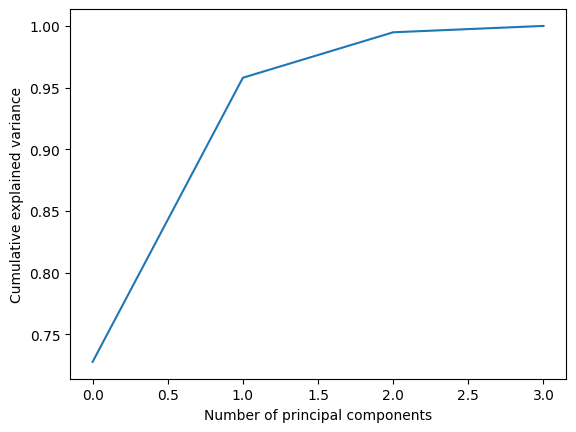

In [61]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of principal components')
plt.ylabel('Cumulative explained variance')
plt.show()

In [62]:
pca_2=PCA(n_components=4)
pca_2=pca_2.fit(transformed_df)
pca_2d=pca_2.transform(transformed_df)

In [63]:
pca_2d

array([[-2.26454173e+00,  5.05703903e-01,  1.21943348e-01,
        -2.30733235e-02],
       [-2.08642550e+00, -6.55404729e-01,  2.27250832e-01,
        -1.03208244e-01],
       [-2.36795045e+00, -3.18477311e-01, -5.14796236e-02,
        -2.78252250e-02],
       [-2.30419716e+00, -5.75367713e-01, -9.88604444e-02,
         6.63114622e-02],
       [-2.38877749e+00,  6.74767397e-01, -2.14278490e-02,
         3.73972870e-02],
       [-2.07053681e+00,  1.51854856e+00, -3.06842583e-02,
        -4.39877494e-03],
       [-2.44571134e+00,  7.45626750e-02, -3.42197636e-01,
         3.80965668e-02],
       [-2.23384186e+00,  2.47613932e-01,  8.25744645e-02,
         2.55051623e-02],
       [-2.34195768e+00, -1.09514636e+00, -1.53562399e-01,
         2.67938291e-02],
       [-2.18867576e+00, -4.48629048e-01,  2.46559522e-01,
         3.99073035e-02],
       [-2.16348656e+00,  1.07059558e+00,  2.64009373e-01,
        -1.53011377e-02],
       [-2.32737775e+00,  1.58587455e-01, -1.00165616e-01,
      

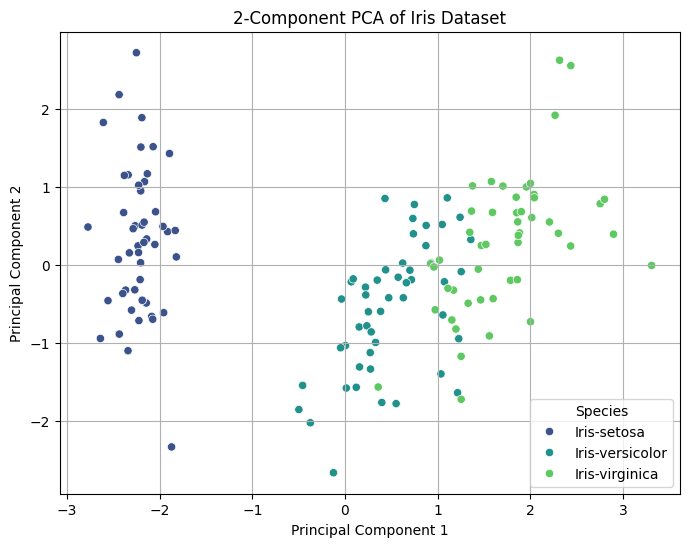

In [64]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca_2d[:,0], y=pca_2d[:,1], hue=iris_df['Species'], palette='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('2-Component PCA of Iris Dataset')
plt.grid(True)
plt.show()

In [68]:
np.dot(pca_2.components_[0],pca_2.components_[1])

np.float64(-4.440892098500626e-16)

In [69]:
cov_mat=np.cov(pca_2d,rowvar=False)
cov_mat

array([[ 2.93035378e+00,  1.43799605e-16,  9.03223803e-16,
         2.08068278e-16],
       [ 1.43799605e-16,  9.27403622e-01, -1.81117680e-16,
         3.23520067e-16],
       [ 9.03223803e-16, -1.81117680e-16,  1.48342226e-01,
        -3.35954756e-16],
       [ 2.08068278e-16,  3.23520067e-16, -3.35954756e-16,
         2.07460140e-02]])